## Zomato Data Analysis Project

#### Step1: Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

#### Step2: Evaluation of Data

In [10]:
data =  pd.read_csv('Zomato data .csv')
data.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [22]:
data.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9,47,200,Dining


In [23]:
print('No of Rows :', data.shape[0])

No of Rows : 148


In [12]:
print('No of Cols:', data.shape[1])

No of Cols: 7


In [13]:
print('Info of Data \n \n',data.info)

Info of Data 
 
 <bound method DataFrame.info of                       name online_order book_table   rate  votes  \
0                    Jalsa          Yes        Yes  4.1/5    775   
1           Spice Elephant          Yes         No  4.1/5    787   
2          San Churro Cafe          Yes         No  3.8/5    918   
3    Addhuri Udupi Bhojana           No         No  3.7/5     88   
4            Grand Village           No         No  3.8/5    166   
..                     ...          ...        ...    ...    ...   
143       Melting Melodies           No         No  3.3/5      0   
144        New Indraprasta           No         No  3.3/5      0   
145           Anna Kuteera          Yes         No  4.0/5    771   
146                 Darbar           No         No  3.0/5     98   
147          Vijayalakshmi          Yes         No  3.9/5     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800

In [14]:
data.dtypes

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

In [17]:
data.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


#### Step 3: Format the Data

In [20]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)
data['rate'] = data['rate'].apply(handleRate)
print(data.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


#### What type of the Resturant do the majority of customers order from

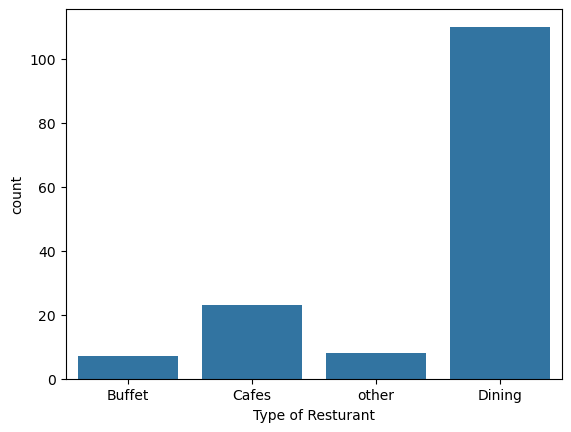

In [24]:
sns.countplot(x = data['listed_in(type)'])
plt.xlabel('Type of Resturant')
plt.show()

#### Votes Each of the Resturant received

                 votes
listed_in(type)       
Buffet            3028
Cafes             6434
Dining           20363
other             9367


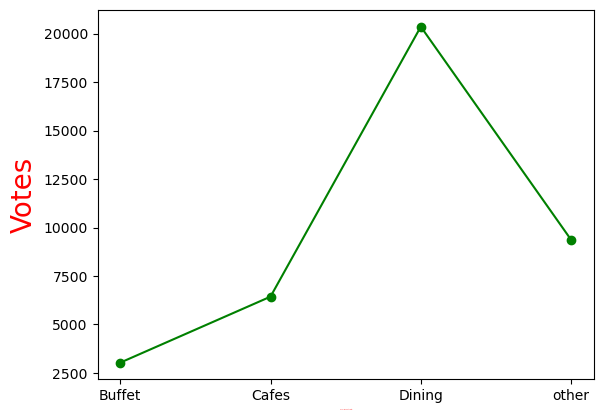

In [29]:
group_data = data.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes' : group_data})
print (result)
plt.plot(result, c = 'green' , marker = "o")
plt.xlabel('Type of resturant' , c = 'red' , size = 0)
plt.ylabel('Votes' , c = 'red', size = 20)
plt.show()

#### What are the Ratings that the Majority of resturant have received

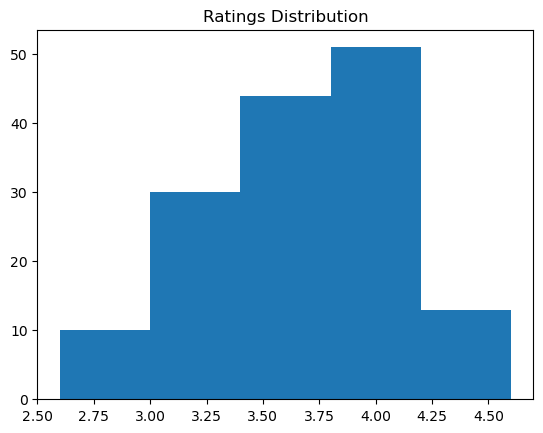

In [40]:
plt.hist(data['rate'],bins = 5) #bins will seprate it
plt.title('Ratings Distribution')
plt.show()

#### The Majority of Couples prefer resturants with an approximate cost of 300 rupees.

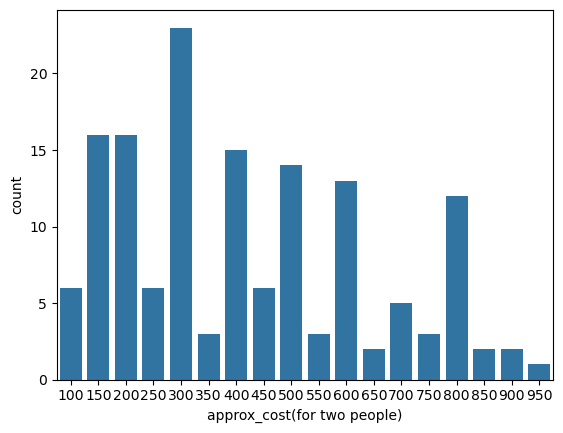

In [42]:
couple_data = data['approx_cost(for two people)']
sns.countplot(x = couple_data)
plt.show()

#### Weather Online orders receive higher ratings than offline orders

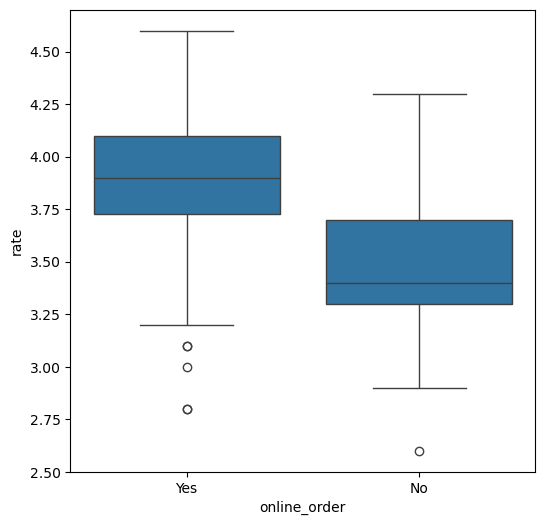

In [47]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order' , y = 'rate' , data = data)
plt.show()

#### Which type of Resturant received more Offline orders, so that Zomato can provide those customers with some good Offers ?

online_order     No  Yes
listed_in(type)         
Buffet            3    4
Cafes             8   15
Dining           77   33
other             2    6


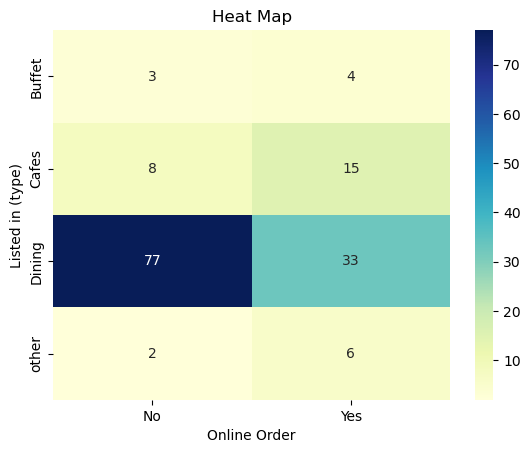

In [51]:
pivot_table = data.pivot_table(index = 'listed_in(type)',
                               columns = 'online_order',
                               aggfunc = 'size',
                               fill_value = 0

                              )
sns.heatmap(pivot_table , annot = True , cmap = 'YlGnBu', fmt = 'd')
print(pivot_table)
plt.title('Heat Map')
plt.xlabel("Online Order")
plt.ylabel('Listed in (type)')
plt.show()